<a href="https://colab.research.google.com/github/roser740/Data-Analytics/blob/main/TASQUES%20S8/TS8_01_roser_carrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tasca S8.01. Analítica de dades en Pandas**

En aquest sprint treballaràs un procés complet d'**Exploratory Data Analysis** (EDA) utilitzant Python i Pandas, simulant una situació real d'anàlisi de dades dins d'una empresa.

L'objectiu no és només obtenir resultats, sinó entendre el dataset, detectar problemes, prendre decisions analítiques i justificar-les, seguint una metodologia estructurada similar a la que utilitzaria un/a analista de dades en un entorn professional.

El sprint està organitzat en tres nivells de dificultat, on cada nivell aprofundeix més en:

*   Qualitat de les dades.
*   Capacitat de diagnòstic.
*   Tractament d'errors.
*   Enriquiment del dataset.

Procura que el teu codi sigui clar i organitzat.

# **📚 Llibreries**

Importem les llibreries necessaries per desenvolupar els diferents exercicis.

In [1206]:
import pandas as pd # llibreria per gestionar dataframes
import numpy as np # llibreria per computació numèrica i científica
import codecs # mòdul per codificar i descodificar dades en diferents formats
import json # llibreria per processar i interpretar text en format JSON
import seaborn as sns # llibreria de visualització de dades
import matplotlib.pyplot as plt # llibreria per fer gràfiques

## 💢 **Dades**

En diversos exercicis hem d'exportar dades en diversos formats. Aquestes dades les guardarem a una carpeta del Drive.

Per poder utilitzar el Drive des de Google Colab primer l'hem de muntar:

In [1207]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **⭕ Funcions generals**

Definim funcions que aprofitem d'altres sprints i que utilitzem en diferents exercicis.

In [1208]:
def mostrar_dataframe(df, títol):
#Presenta les dades en format tabular amb el títol indicat

    # Mostrem títol
    print("\n" + "="*100)
    print(títol)
    print("="*100)
    # La funció display mostra les dades del dataframe en format taula.
    # Utilitzem la propietat style per amagar la columna de l'índex.
    display(df)

# **Nivell 1 - EDA estructurat i neteja bàsica**

Tenim un dataset d'empleats obtingut a partir d'una enquesta interna. Abans de poder extreure conclusions, cal assegurar-nos que les dades són correctes, consistents i analitzables.

# **Exercici 1: Exploració inicial del dataset**

🎯 **Objectiu:** entendre l’estructura general del dataset i detectar possibles problemes abans de començar a netejar o transformar dades.

En aquest exercici has de realitzar una exploració inicial del DataFrame per respondre, com a mínim, a les següents preguntes:
*   Quantes files i columnes té el dataset?
*   Quin tipus de dades conté cada columna?
*   Hi ha files duplicades?
*   Les dades semblen coherents a primera vista?
*   Detectes possibles problemes o inconsistències evidents?

Per fer-ho, hauràs de:
*   Analitzar les dimensions del dataset
*   Mostrar una mostra representativa de files
*   Revisar els tipus de variables
*   Detectar files duplicades
*   Les dades semblen coherents a primera vista?
*   Identificar i descriure possibles problemes inicials (sense solucionar-los encara)

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Obrir el fitxer i carregar dades en un dataframe.
2. Obtenir les dimensions del dataframe.
3. Mostrar 10 files del dataframe.
4. Mostrar el tipus de dades de cada columna.
5. Detectar files duplicades.
6. Detectar DNI's duplicats.
7. Detectar camps nuls.
8. Detectar valors incorrectes o incoherents en els diferents camps:
    *   a. Problemes de codificació i accentuació
    *   b. DNI
    *   c. Data de naixement
    *   d. Gènere
    *   e. Salari mensual
    *   f. Fills
    *   g. Cotxe

## 🧩 **Implementació**



### **1. Càrrega de les dades**


In [1209]:

# url: ruta on trobem l'arxiu amb les dades que cal analitzar
# header: número de fila de l'arxiu excel on trobem el nom de les columnes
# index_col: número de columna que conté els valors de l'índex
url = "https://github.com/roser740/Data-Analytics/raw/main/TASQUES%20S8/sprint8_complex.xlsx"
df = pd.read_excel(url, header=3, index_col=0)


### **2. Obtenir les dimensions del dataframe**

In [1210]:
print ("Número de files: ", df.shape[0])
print ("Número de columnes: ", df.shape[1])

Número de files:  1007
Número de columnes:  19


### **3. Mostra de les dades del dataframe**
Mostrem les 10 primeres files del dataframe per donar una ullada a les dades i fer-nos una idea dels problemes que haurem de solucionar per obtenir un conjunt de dades consistent.

In [1211]:
mostrar_dataframe(df.head(10), "MOSTRA DE LES DADES")


MOSTRA DE LES DADES


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1.0,8.0,1978.0,D,"2,069 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,GÃ³mez Vila,36998038E,Espanya,Palma,25.0,9.0,1971.0,D,"2,349 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,LÃ³pez,47376585K,Espanya,Barcelona,8.0,9.0,1962.0,H,"2,855 â‚¬",True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
540,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,8.0,3.0,1963.0,D,"1,338 â‚¬",NaN,True,Grup B,Analista junior,0.0,False,NaN,NaN,7.6
9,Alba,GarcÃ­a,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1


### **4. Tipus de dades**
Mostrem el tipus de dades corresponent a cada camp. Trobem dos tipus de dades:
*   **object:** pot contenir qualsevol tipus de dades.
*   **float64:** tipus numèric amb decimal.

Observem:
*   els camps **Fills**, **No Fills** i **Te_cotxe** estan definits com a object però contenen valors booleans (True i False).
*   el camp **Salari mensual** conté valors numèrics però està definit com a object.
*   la resta de camps definits com a object contenen cadenes de text.



In [1212]:
print(df.dtypes)

Nom                            object
Cognoms                        object
DNI                            object
País d'origen                  object
Ciutat                         object
Dia de Naixement              float64
Mes de Naixement              float64
Any de Naixement              float64
Gènere                         object
Salari mensual                 object
Fills                          object
No Fills                       object
Grup Professional              object
CÃ rrec                        object
Nombre_fills                  float64
Te_cotxe                       object
Km_anuals                     float64
Consum_mitja_L_100km          float64
Temperatura_mitjana_ciutat    float64
dtype: object


### **5. Files duplicades**

Mostrem els registres que tenen tots els camps iguals ordenats per DNI.

Observem que hi ha 4 registres duplicats.

Utilitzem la funció **duplicated** que ens retorna una llista de valors booleans que indiquen si la fila corresponent és duplicada (True) o única (False) --> (False, False,..., True, False, True, ...)

El paràmetre **keep** ens permet indicar quines files duplicades marquem com a True:
*   **keep = 'first' :** marquem les files duplicades com a True excepte la primera.
*   **keep = 'last' :** marquem les files duplicades com a True excepte l'última.
*   **keep = 'False' :** marquem totes les files duplicades com a True.



In [1213]:

# Obtenim una llista de valors booleans on les files duplicades contenen valor True(1) i les altres False (0).
files_duplicades = df.duplicated(keep = False)
# Sumem els valors de la llista obtinguda.
# Com que les files duplicades tenen valor True (1) obtenim el número total de files duplicades.
print("Número de files duplicades: ", files_duplicades.sum())
# Mostrem les files duplicades ordenades per DNI.
mostrar_dataframe(df[files_duplicades].sort_values(by='DNI'), "FILES DUPLICADES")


Número de files duplicades:  8

FILES DUPLICADES


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
757,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
464,Ida,Karlsen Eriksen,55283701C,Noruega,Oslo,2.0,9.0,1992.0,D,"1,614 â‚¬",True,NaN,Grup B,Analista,3.0,NaN,NaN,NaN,10.6
1001,Ida,Karlsen Eriksen,55283701C,Noruega,Oslo,2.0,9.0,1992.0,D,"1,614 â‚¬",True,NaN,Grup B,Analista,3.0,NaN,NaN,NaN,10.6
730,Claudia,Gil Ferrer,55297384F,Espanya,ValÃ¨ncia,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1003,Claudia,Gil Ferrer,55297384F,Espanya,ValÃ¨ncia,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
372,Alba,MuÃ±oz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1002,Alba,MuÃ±oz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7


### **6. DNI's duplicats**
Mostrem els registres que tenen el DNI duplicat ordenats per DNI. Obtenim un conjunt de 24 registres que inclouen els 8 registres anteriors on tots els camps són iguals a més del DNI.

La funció duplicated té el paràmetre **subset** que ens permet indicar quina columna hem de mirar per trobar duplicats.

In [1214]:

# Obtenim una llista de valors booleans on les files amb DNI duplicat contenen valor True(1) i les altres False (0).
dni_duplicats = df.duplicated(subset=['DNI'], keep= False)
# Sumem els valors de la llista per obtenir el número total de registres amb DNI duplicat.
print("Número de DNI's duplicats: ", dni_duplicats.sum())
# Mostrem els registres amb el DNI duplicat ordenats per DNI
mostrar_dataframe(df[dni_duplicats].sort_values(by='DNI'), "DNI's DUPLICATS")

Número de DNI's duplicats:  24

DNI's DUPLICATS


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676 â‚¬",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2
250,Laia,Navarro Vila,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,1235 euros,True,True,Grup D,Analista junior,0.0,False,NaN,NaN,10.3
759,Oriol,GÃ³mez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000 â‚¬",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7
758,Oriol,GÃ³mez,16618423V,Espanya,MÃ laga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
754,Oriol,GÃ³mez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358 â‚¬,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
654,Oriol,GÃ³mez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
692,Alexia,PÃ©rez DÃ­az,49529438G,Espanya,MÃ laga,12.0,10.0,1981.0,Dona,1663â‚¬,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9
558,Alexia,PÃ©rez DÃ­az,49529438G,Espanya,MÃ laga,12.0,10.0,1981.0,Dona,"1,176 â‚¬",NaN,True,Grup A,Data Analyst,0.0,False,NaN,NaN,38.0
757,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9


### **7. Valors nuls**
Mostrem el número de valors nuls (NaN) que hi ha per cada camp. Observem que només hi ha un registre amb valors nuls en els camps que identifiquen el treballador.

La funció **isna()** ens retorna un dataframe de valors booleans que ens indiquen per cada posició si conté un valor nul (True) o no (False).

En aplicar la funció **sum()** a aquest dataframe obtenim el número total de valors nuls per cada camp.


In [1215]:
print("Valors nuls" )
print(df.isna().sum())


Valors nuls
Nom                             1
Cognoms                         1
DNI                             1
País d'origen                   1
Ciutat                          1
Dia de Naixement                1
Mes de Naixement                1
Any de Naixement                1
Gènere                         41
Salari mensual                  1
Fills                         588
No Fills                      422
Grup Professional               2
CÃ rrec                         2
Nombre_fills                  298
Te_cotxe                      349
Km_anuals                     692
Consum_mitja_L_100km          746
Temperatura_mitjana_ciutat     71
dtype: int64


### **8. Detecció de dades incorrectes o incoherents**
Analitzarem els valors dels diferents camps per detectar valors incorrectes o incoherents.

#### **a. Problemes de codificació i accentuació**
Observem alguns problemes de codificació i accentuació en el nom de les columnes (CÃ rrec ) i també en els camps que contenen text:
*   **Nom:** ChloÃ©, AdriÃ ...
*   **Cognoms:** MuÃ±oz, GÃ³mez ...
*   **País d'origen:** FranÃ§a, ItÃlia ...
*   **Ciutat:** MÃ laga, ValÃ¨ncia ...
*   **Càrrec:** TÃ¨cnic IT ...

#### **b. DNI**
Mostrem els registres amb longitud del camp DNI diferent de 9. Observem que hi ha dos registres que haurem d'eliminar ja que no contenen informació vàlida.

In [1216]:
df[df['DNI'].str.len()!=9]

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1006,???,###,XXXX,Narnia,Desconeguda,-99.0,99.0,3000.0,??,molts,NaN,NaN,Z,???,NaN,NaN,NaN,NaN,NaN


#### **c. Data de naixement**
Analitzem els camps que contenen la data de naixement per detectar si hi ha valors fora de rang:
*   **Dia de naixement:** pot contenir valors entre 1 i 31.
*   **Mes de naixement:** pot contenir valors entre 1 i 12.
*   **Any de naixement:** pot contenir valors entre 1950 i 2009.

Com que les dades corresponen a una enquesta de treballadors feta l'any 2025 els anys de naixement han de correspondre a persones en edat de treballar: de 16 anys a 75 anys.




In [1217]:
# Definim la condició per seleccionar els registres que estan fora de rang en els camps de la data de naixement
condicio = (df['Dia de Naixement']<1) | (df['Dia de Naixement']>31) | (df['Mes de Naixement']<1) | (df['Mes de Naixement']>12)
condicio = condicio | (df['Any de Naixement']<1950) | (df['Any de Naixement']>2009)
# Seleccionem les files que compleixen la condició definida i mostrem totes les columnes
df.loc[condicio, :]

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
9,Alba,GarcÃ­a,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1
39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,H,dos mil,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,NaN
41,Paul,Richard Laurent,43567615Z,FranÃ§a,Bordeaux,32.0,99.0,2019.0,Dona,"1,967 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,False,NaN,NaN,15.2
47,Aina,FernÃ¡ndez,38468360C,Espanya,Zaragoza,-5.0,0.0,3000.0,Home,1939 euros,True,NaN,Grup C,Analista,1.0,True,78064.0,NaN,NaN
53,Aina,Serra,29226889H,Espanya,ValÃ¨ncia,0.0,0.0,2019.0,F,"1,866 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,NaN,False,NaN,NaN,21.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,David,PÃ©rez,52298598B,Espanya,Murcia,-5.0,0.0,2019.0,Dona,779 â‚¬,NaN,True,Grup A,Analista junior,0.0,NaN,NaN,NaN,19.0
63,Ida,Johansen Kristiansen,41407343V,Noruega,Bergen,32.0,99.0,2019.0,D,"2,759 â‚¬",NaN,True,Grup C,Senior analyst,NaN,False,NaN,NaN,9.1
981,Giulia,Romano,34747698K,ItÃ lia,Torino,32.0,0.0,2026.0,D,"1,316 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,NaN,True,20000.0,9.1,38.0
996,LucÃ­a,Roca Vila,21702378D,Espanya,Alacant,32.0,0.0,1940.0,NaN,1158â‚¬,NaN,True,Grup A,Data Analyst,NaN,NaN,NaN,NaN,19.4


#### **d. Gènere**
Mostrem els diferents valors que conté el camp Gènere i el número de registres que hi ha per cada valor.

La funció **groupby** ens permet agrupar les dades del dataframe per un camp concret. El paràmetre **dropna** ens permet indicar si volem excloure els valors nuls (dropna = True) o no (dropna = False).

Observem que el camp Gènere conté diferents codis per representar el mateix concepte:
*   **dona:** D, Dona, F
*   **home:** H, Home, M
*   **sexe no determinat**: ??, A, NC, NaN



In [1218]:
# Agrupem pel camp Gènere tenint en compte els valors nuls i comptem el número de DNI's per cada valor
df.groupby(['Gènere'],dropna=False)['DNI'].count()

,DNI
Gènere,
??,1
A,24
D,325
Dona,120
F,107
H,280
Home,52
M,34
NC,23


#### **e. Salari mensual**
Agrupem les dades pel camp Salari mensual per veure els diferents valors i també donem una ullada a l'arxiu origen.

Observem que aquest camp té diferents formats:
*   per indicar la moneda: euros, â‚¬ ...
*   per indicar milers: 1298 (res), 1,654 (coma), 1.106 (punt)

També conté valors no numèrics:
*   dos mil, mil vuit-cents, tres mil
*   molts, n/d



In [1219]:
df.groupby(['Salari mensual'])['DNI'].count()

,DNI
Salari mensual,
"1,000 â‚¬",1
"1,001 â‚¬",1
"1,002 â‚¬",1
"1,003 â‚¬",2
"1,005 â‚¬",1
...,...
dos mil,7
mil vuit-cents,9
molts,1


#### **f. Fills**
Els camps **Fills**, **No Fills** i **Nombre_fills** estan relacionats.

Agrupem les dades per aquests tres camps i observem que hi ha incoherencies. Trobem registres que tenen Nombre_fills = 0  i el camp Fills = True i també regsitres que tenen Nombre_fills<>0 i el camp No Fills = True.

A més els camps Fills i No Fills són redundants, amb un camp que ens indiqui si el treballador té fills o no n'hi ha prou.


In [1220]:
df.groupby(['Nombre_fills','Fills','No Fills'],dropna=False)['DNI'].count()

Nombre_fills  Fills  No Fills
0.0           True   True         34
              NaN    NaN          15
                     True        263
1.0           True   NaN         160
                     False         1
                     True          6
              NaN    NaN           2
                     True          2
2.0           True   NaN          73
                     True          1
              NaN    NaN           1
                     True          4
3.0           True   NaN          60
                     True          3
              NaN    NaN           1
                     True          1
4.0           True   NaN          77
                     True          1
              NaN    NaN           1
                     True          2
5.0           NaN    NaN           1
NaN           True   True          3
              NaN    NaN          30
                     True        264
Name: DNI, dtype: int64

#### **g. Cotxe**
Els camps **Te_cotxe**, **km_anuals** i **Consum_mitja_L_100km** estan relacionats.

Agrupem les dades per aquests tres camps i observem que hi ha incoherencies i valors nuls. Trobem registres que tenen km_anuals negatius i també alguns registres que no tenen km_anuals i si que tenen consum mitjà.

In [1221]:
df.groupby(['Te_cotxe','Km_anuals','Consum_mitja_L_100km'],dropna=False)['DNI'].count()

Te_cotxe  Km_anuals  Consum_mitja_L_100km
True      -50.0      NaN                       6
           50.0      NaN                       1
           2938.0    0.5                       1
           3920.0    NaN                       1
           3936.0    12.9                      1
                                            ... 
           NaN       25.0                      1
                     NaN                      15
NaN        NaN       NaN                     348
False      0.0       NaN                       4
           NaN       NaN                     326
Name: DNI, Length: 240, dtype: int64

#### **h. Càrrec**
Analitzem el camp de càrrec i observem que hi ha alguns càrrecs que són el mateix però estan escrits de diferent manera.

In [1222]:
df.groupby('CÃ rrec',dropna=False)['DNI'].count()

,DNI
CÃ rrec,
???,1
Admin.,6
Administratiu,105
Analista,116
Analista junior,107
Analyst,9
Cap de Projecte,13
Cap de projecte,94
Data Analyst,142


# **Exercici 2: Validacions bàsiques de les dades i decisions d'eliminació**

🎯 **Objectiu:** assegurar que les dades compleixen unes **condicions mínimes de qualitat** i determinar quines files poden continuar sent analitzades i quines s'han de descartar.
En aquest exercici hauràs de validar aspectes clau del dataset que són crítics en qualsevol context real d'anàlisi de dades, prenent decisions justificades sobre la validesa o eliminació de registres.

Aspectes a validar:

  » Existeixen identificadors únics (DNI) per a cada persona?

  » Què faràs amb les files duplicades o registres repetits?

  » Hi ha valors obligatoris que falten o informació incoherent?

  » Detectes formats incorrectes, errors de codificació o valors impossibles?

Concretament, hauràs de:

  » Corregir possibles problemes de codificació i accentuació en els noms de les columnes i en els valors de text, si escau.

  » Detectar i eliminar files duplicades exactes, indicant quants registres s'han eliminat.

  » Comprovar la unicitat del DNI. En cas de detectar DNIs duplicats, hauràs d'analitzar la coherència de la informació associada i descartar o anul·lar els registres que no siguin fiables, justificant clarament la decisió presa.

  » Identificar els camps clau que no haurien de contenir valors nuls, detectar registres amb informació insuficient i eliminar únicament aquelles files completament buides o amb informació irrecuperable o no substituïble, explicant per què no és possible ni raonable imputar-les.



# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Eliminar files duplicades exactes.
2. Eliminar files amb camps clau amb valors nuls o incorrectes.
3. Corregir problemes de codificació i accentuació.
      *   Correcció dels noms de les columnes
      *   Correcció del contingut de les columnes
4. Detectar DNIs duplicats i descartar els erronis.
5. Actualització format del camp Salari mensual.

## 🧩 **Descomponent el problema: naixement de les funcions**

### **1. Eliminar files duplicades**
Hem detectat que hi ha files duplicades és a dir registres que tenen el mateix contingut. En aquest cas per cada conjunt de duplicats eliminem els registres duplicats excepte el primer.

In [1223]:
def eliminar_files_duplicades (df):

  print("1.ELIMINACIÓ DE FILES DUPLICADES")
  files_duplicades = df.duplicated(keep = 'last')
  print("    Número de files duplicades: ", files_duplicades.sum())
  print ("    Eliminem files duplicades...")
  # Esborra els duplicats. Per defecte guarda el primer registre.
  df.drop_duplicates(inplace=True)



### **2. Eliminar registres amb DNI nul o incorrecte**
Hem detectat un registre amb DNI nul i un registre amb DNI incorrecte. Els eliminem ja que són registres que no contenen dades vàlides.

In [1224]:
def eliminar_nuls (df):

  print("2. ELIMINACIÓ DE REGISTRES AMB DNI NUL O INCORRECTE")
  dni_nuls = df.isna()['DNI']
  print("    Número de files amb DNI nul: ", dni_nuls.sum())
  print ("    Eliminem files amb DNI nul...")
  df.dropna(subset = ['DNI'], inplace = True)

  dni_incorrecte = df['DNI'].str.len()!=9
  print("    Número de files amb DNI incorrecte: ", dni_incorrecte.sum())
  print ("    Eliminem files amb DNI incorrecte...")
  df.drop([1006], inplace=True)

### **3. Correcció de problemes de codificació i accentuació**

El problema més comú amb els accents i la codificació és que el text originalment en UTF-8 es llegeix incorrectament com si fos en Latin-1 (ISO-8859-1). Per solucionar-ho, cal "desfer" la lectura incorrecta (codificant de nou a Latin-1) i després "corregir" la lectura (descodificant a UTF-8).

Aquest problema afecta tant els noms de les columnes com els valors de text dins de les columnes. Corregim els noms de les columnes i, posteriorment, apliquem la mateixa correcció als valors de text de totes les columnes amb tipus dades 'object'.

In [1225]:
def descodificar (text):
# Funció que retorna el text que rep com a paràmetre sense errors.

  if isinstance (text, str): # Si el text és un string

    # Pas 1: Intentar 'desescapar' les seqüències Unicode literals (per exemple, '\u00f1' -> 'ñ')
    # Utilitzem r'\u' per assegurar que Python interpreta '\u' literalment i no com una seqüència d'escapament Unicode incompleta.
    if r'\u' in text:
        try:
            # codecs.decode converteix les seqüències literals \uXXXX al seu caràcter Unicode
            text = codecs.decode(text, 'unicode_escape')
        except (UnicodeDecodeError):
            pass # Si falla, no és una seqüència d'escapament literal o està mal formatada, continuem.

    # Pas 2: Intentar corregir el 'mojibake' d'una mala descodificació de latin1 a utf-8 (per exemple, 'Ã±' -> 'ñ')
    try:
      return text.encode('latin-1').decode('utf-8').strip()
    except (UnicodeEncodeError, UnicodeDecodeError):
      # Si l'encoding a latin-1 falla o el decoding des de utf-8 falla,
      # pot ser que ja estigui correcte o sigui irreparable per aquest mètode.
      return text.strip()

  # Si el contingut no és un string, no intenta descodificar i retorna el contingut original
  return text

In [1226]:
def correccions_codificacio (df, titol):

  print(titol)
  # Correcció dels noms de les columnes
  print ("    Corregim els noms de les columnes...")
  df.columns = [descodificar(col) for col in df.columns]

  # Correcció dels contingut de les columnes
  print ("    Corregim els valors de text de les columnes 'object'...")
  for col in df.columns:
    if df[col].dtype == 'object':
      df[col] = df[col].apply(descodificar)


### **4. Correcció de DNI's duplicats**

Analitzem els DNI duplicats:
*   15909601K: deixarem el més actual (Id: 604) ja que té les dades més actualitzades (sou, càrrec, fills, cotxe). Del registre antic hauríem de conservar els cognoms.
*   16618423V: 4 registres, deixarem el més actual (Id:759) ja que té les dades més actualitzades (ciutat, sou, càrrec, nº fills). Cal actualitzar Gènere=H.
*   49529438G: deixarem el més actual (Id:692)  ja que té les dades més actualitzades (sou, càrrec, dades cotxe).
*   54013571W: mateix DNI, 2 noms diferents, dates naixement diferents --> esborrem els dos registres ja que no tenim dades suficients per determinar a qui correspon el DNI.
*   90585882A: mateix DNI, 6 registres, assignar a Sara Serra (Id:1000) ja que 3 de les entrades corresponen a ella. Deixarem el registre més actual ja que té les dades més actualitzades (salari).

En resum les accions que hem de fer són:
*   Actualitzar dos registres:
    *   Cognoms (15909601K) = Navarro Vila
    *   Gènere (16618423V) = H
*   Esborrar registres corresponents al DNI = 54013571W (Id=89, Id=142)
*   Esborrar duplicats conservant el registre més actual de cada grup de duplicats.






In [1227]:

def correccions_dni_duplicats (df):

  print("4. CORRECCIÓ I ELIMINACIÓ DE REGISTRES AMB DNI DUPLICAT")

  dni_duplicats = df.duplicated(subset=['DNI'], keep= False)
  print("    Número de DNI's duplicats: ", dni_duplicats.sum())

  print ("    Corregim valors de les files amb DNI duplicat...")
  df.loc[df['DNI'] == '15909601K', 'Cognoms'] = 'Navarro Vila'
  df.loc[df['DNI'] == '16618423V', 'Gènere'] = 'H'

  print ("    Eliminem files amb DNI duplicat...")
  dni_duplicats = df.duplicated(subset=['DNI'], keep= 'last')
  print("    Número de DNI's duplicats que eliminem: ",dni_duplicats.sum()+1)
  df.drop([89, 142], inplace=True)
  df.drop_duplicates(subset=['DNI'], keep='last', inplace=True)


### **5. Actualització format del camp Salari mensual**

Analitzem el camp de Salari mensual.
Observem que aquest camp té diferents formats:
*   per indicar la moneda: euros, â‚¬ ...
*   per indicar milers: 1298 (res), 1,654 (coma), 1.106 (punt)

També conté valors no numèrics:
*   dos mil, mil vuit-cents, tres mil
*   molts, n/d

En resum les accions que cal fer són:
*   substituir les valors (euros, â‚¬)  per blanc.
*   substituir coma i punt per blanc.
*   substituir dos mil, mil vuit-cents, tres mil per valor numèric
*   substituir molts, n/d per NaN.

In [1228]:
def correccions_salari_mensual (df):

  print("4. ACTUALITZACIÓ SALARI MENSUAL")

  # Convertim el camp Salari mensual a string per poder utilitzar la funció replace
  df['Salari mensual'] = df['Salari mensual'].astype(str)

  # Substituïm 'euros' i 'â‚¬' per blanc
  print ("    Substituim les valors (euros, â‚¬) per blanc...")
  df['Salari mensual'] = df['Salari mensual'].str.replace('euros', '', regex=False)
  df['Salari mensual'] = df['Salari mensual'].str.replace('â‚¬', '', regex=False)

  # Substituïm punt i comes per blanc
  print ("    Substituim els punt i les comes per blanc...")
  df['Salari mensual'] = df['Salari mensual'].str.replace('.', '', regex=False)
  df['Salari mensual'] = df['Salari mensual'].str.replace(',', '', regex=False)

  # Esborrem els possibles espais que hagin quedat al principi o al final
  df['Salari mensual'] = df['Salari mensual'].str.strip()

  # Substituïm valors alfanumèrics per numèrics
  print ("    Substituim els valors alfanumèrics per valors numèrics...")
  df.loc[df['Salari mensual'] == 'dos mil', 'Salari mensual'] = 2000
  df.loc[df['Salari mensual'] == 'mil vuit-cents', 'Salari mensual'] = 1800
  df.loc[df['Salari mensual'] == 'tres mil', 'Salari mensual'] = 3000

  # Convertim la columna a numèric substituïnt els valors no numèrics ('n/d'...) per NaN
  print ("    Convertim el salari mensual a numèric...")
  df['Salari mensual'] = pd.to_numeric(df['Salari mensual'], errors='coerce')

## **⭕ Funció principal**

In [1229]:
def main_validacio(df):
  eliminar_files_duplicades(df)
  eliminar_nuls(df)
  correccions_codificacio (df, "3. CORRECIÓ PROBLEMES DE CODIFICACIÓ I ACCENTUACIÓ")
  correccions_dni_duplicats (df)
  correccions_salari_mensual (df)

  mostrar_dataframe(df, "DATAFRAME ACTUALITZAT")

## ▶ **Execució**

In [1230]:
main_validacio(df)

1.ELIMINACIÓ DE FILES DUPLICADES
    Número de files duplicades:  4
    Eliminem files duplicades...
2. ELIMINACIÓ DE REGISTRES AMB DNI NUL O INCORRECTE
    Número de files amb DNI nul:  1
    Eliminem files amb DNI nul...
    Número de files amb DNI incorrecte:  1
    Eliminem files amb DNI incorrecte...
3. CORRECIÓ PROBLEMES DE CODIFICACIÓ I ACCENTUACIÓ
    Corregim els noms de les columnes...
    Corregim els valors de text de les columnes 'object'...
4. CORRECCIÓ I ELIMINACIÓ DE REGISTRES AMB DNI DUPLICAT
    Número de DNI's duplicats:  16
    Corregim valors de les files amb DNI duplicat...
    Eliminem files amb DNI duplicat...
    Número de DNI's duplicats que eliminem:  12
4. ACTUALITZACIÓ SALARI MENSUAL
    Substituim les valors (euros, â‚¬) per blanc...
    Substituim els punt i les comes per blanc...
    Substituim els valors alfanumèrics per valors numèrics...
    Convertim el salari mensual a numèric...

DATAFRAME ACTUALITZAT


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,1469.0,True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,2718.0,NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358.0,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,1478.0,True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,1284.0,NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,Jordi,Hernández,67755039Y,Espanya,Zaragoza,12.0,10.0,1961.0,Dona,1074.0,NaN,NaN,Grup A,Data Analyst,1.0,True,80000.0,12.0,12.0
998,Chloé,Dubois,66354268T,França,Nice,2.0,12.0,1958.0,H,1954.0,True,NaN,Grup B,Data Analyst,1.0,NaN,NaN,NaN,11.7
999,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,H,2010.0,True,NaN,Grup C,Analista,1.0,False,NaN,NaN,-10.0
1000,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,1073.0,NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8


# **Exercici 3: Transformacions necessàries i preparació del dataset**

🎯 Objectiu: preparar el dataset perquè sigui coherent, analitzable i estructuralment correcte abans de realitzar qualsevol anàlisi descriptiva.
En aquest exercici hauràs d'aplicar transformacions bàsiques però essencials, orientades a millorar la qualitat de les dades i facilitar l'anàlisi posterior.

**Aspectes a revisar i transformar:**

» Els valors categòrics estan normalitzats i són consistents?

» Els valors nuls són coherents amb la informació disponible?

» Hi ha redundància de variables que pugui generar problemes analítics?

» Les variables contextuals (com temperatura, salari) estan completes i preparades per a l'anàlisi?

**Concretament, hauràs de:**

» Normalitzar els valors categòrics per evitar ambigüitats (per exemple, valors que representen el mateix concepte però estan escrits de manera diferent).

» Revisar la coherència dels valors nuls, assegurant que:

*   Les persones que tenen quilometratge anual i consum mitjà associats disposen de cotxe. En els casos en què consti consum mitjà però no quilometratge anual, caldrà decidir com resoldre aquesta incoherència de manera justificada.
*   Les persones que tenen un valor en el nombre de fills efectivament tenen fills.

» Unificar la informació sobre fills en una única columna, ja que mantenir diverses columnes amb informació complementària no és òptim i pot generar problemes analítics (redundància o multicolinealitat).

» Validar la temperatura mitjana. En cas que aquesta informació falti, hauràs d'imputar-la utilitzant un criteri raonable (per ciutat o per un nivell superior justificat).

» Revisar i imputar els salaris faltants, aplicant criteris analítics coherents (com ara càrrec, grup professional, ciutat, gènere o franja d'edat).

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Normalitzar el camp Gènere.
2. Normalitzar els camps Te_cotxe, kms_anuals i consum_mitjà.
3. Normalitzar els camps Fills, No Fills, Nombre_fills.
      *   Correcció dels noms de les columnes
      *   Correcció del contingut de les columnes
4. Revisar el camp data de naixement
5. Revisar el camp salari mensual.
6. Revisar el camp temperatura mitjana.
7. Revisar el camp càrrec.

## 🧩 **Descomponent el problema: naixement de les funcions**

### **1. Normalitzar el camp Gènere**

En l'exploració inicial hem vist que el camp Gènere conté diferents codis per representar el mateix concepte. El que farem és normalitzar el camp per tal que un concepte estigui representat per un sol codi. Tenim els següents casos:

*   **dona:** D, Dona, F --> assignarem D
*   **home:** H, Home, M ---> assignarem H
*   **sexe no determinat**: ??, A, NC, NaN --> assignarem ND

In [1231]:
def assignar_genere (x):
# Funció que rep com a paràmetre el codi inicial i retorna el codi normalitzat

    if (x == 'D') or (x == 'Dona') or (x == 'F'):
        return 'D'
    elif (x == 'H') or (x == 'Home') or (x == 'M'):
        return 'H'
    else:
        return 'ND'

### **2. Normalitzar els camps Te_cotxe, km_anuals, Consum_mitja_L_100km**

Ja hem vist que els camps Te_cotxe, km_anuals i Consum_mitja estan relacionats. Trobem diferents casuístiques:

*   nul, nul, nul  --> 348 registres
_______________________________________________
*   Fals, nul, nul  --> 326 registres
*   Fals, 0.0, nul  --> 4 registres
_______________________________________________
*   True, nul, nul --> 15 registres
*   True, nul, valor --> 1 registre
*   True, valor, nul --> 52 registres
*   True, valor, valor --> la resta

Els treballadors que tenen nul el camp Te_cotxe tampoc tenen informació de quilometratge i consum mitjà per tant suposem que no tenen cotxe i assignarem: False, 0, 0

Als treballadors que no tenen cotxe els assignarem 0 als camps de quilometratge i consum mitjà.

Així el valor False ens indica que no tenim constància que el treballador tingui cotxe.

Hi ha treballadors que tenen cotxe però que no tenen informat el quilometratge i/o el consum mitjà. En aquests casos assignarem aquests camps a 0 ja que no podem saber quin quilometratge o consum mitjà té un treballador concret.

També hi ha alguns registres amb quilometratge negatiu. També l'assignarem a 0.

Així pels treballadors que tenen cotxe el valor 0 als camps quilometratge o consum mitjà ens indica que no disposem d'aquesta informació.










In [1232]:
def normalitzar_cotxe(df):

  # Assignem False als registres que tenen el camp Te_cotxe = NaN
  df.fillna({'Te_cotxe':'False'}, inplace = True)

  # Assignem el valor 0.0 als valors nuls del camp kms_anuals i Consum_mitja_L_100km
  df.fillna({'Km_anuals':0.0}, inplace = True)
  df.fillna({'Consum_mitja_L_100km':0.0}, inplace = True)

  # Assignem el valor 0 al camp km_anuals en els registres que tenen  km_anuals negatius
  df.loc[df['Km_anuals'] < 0.0, 'Km_anuals'] = 0.0

  # Assignem el valor 9999.0 al camp km_anuals en els registres que tenen consum_mitja informat i km_anuals == 0
  #df.loc[(df['Consum_mitja_L_100km'] != 0.0) & (df['Km_anuals'] == 0.0), 'Km_anuals'] = 9999.0



### **3. Normalitzar el camp Fills, No Fills, Nombre_fills**

Hem detectat diversos problemes en els camps referents als fills:
*   hi ha valors nuls.
*   els camps fills i no fills són redundants.
*   hi ha incoherències: nombre de fills <>0 i fills = False...

Considerem que els treballadors Nombre_Fills = null no tenen fills i per tant els assignarem valor 0.

Per normalitzar aquests camps cal fer:
*   Si Nombre_Fills igual a Null assignar el valor 0.
*   Si Nombre_Fills <> 0 aleshores Fills = True.
*   Si Nombre_Fills = 0 aleshores Fills = False.
*   Esliminar la columna No Fills.

In [1233]:
def normalitzar_fills(df):
  # Assignem el valor 0.0 als valors nuls del camp Nombre_fills
  df.fillna({'Nombre_fills':0.0}, inplace = True)
  # Assignem valor al camp Fills en funció del camp Nombre_fills
  df.loc[df['Nombre_fills'] != 0.0, 'Fills'] = True
  df.loc[df['Nombre_fills'] == 0.0, 'Fills'] = False
  # Eliminem la columna No Fills
  df.drop(columns = ['No Fills'], inplace = True)

### **4. Revisar camps de la data de naixement**

En la tasca d'exploració del dataset hem vist que hi ha alguns treballadors que tenen la data de naixement mal informada. Com que no hi ha manera d'aproximar el valor de la data de naixement actualitzarem els camps de la data de naixement d'aquests registres amb un valor fora de rang (99, 9999) que ens indiqui que no tenim el valor correcte.

In [1234]:
def normalitzar_data (df):
  condicio = (df['Dia de Naixement']<1) | (df['Dia de Naixement']>31) | (df['Mes de Naixement']<1)
  condicio = condicio | (df['Mes de Naixement']>12) | (df['Any de Naixement']<1950) | (df['Any de Naixement']>2009)

  # Assignem valors als camps dia, mes i any de naixement incorrectes
  df.loc[condicio, 'Dia de Naixement'] = 99.0
  df.loc[condicio, 'Mes de Naixement'] = 99.0
  df.loc[condicio, 'Any de Naixement'] = 9999.0


### **5. Revisar el camp Salari mensual**

Un cop actualitzada la codificació del camp Salari mensual veiem que hi ha alguns treballadors que no tenen informat el salari mensual. Informnarem el salari d'aquests registres a partir de la mediana del salari dels treballadors que tenen el mateix càrrec.

Utilitzem la mediana enlloc de la mitjana per evitar la influència dels valors extrems.

In [1235]:
def revisar_salari_mensual (df):

  print("4. ACTUALITZACIÓ SALARI MENSUAL")
  print ("    Actualitzem el salari dels treballadors amb valor nul (NaN)...")
  print ("    Assignem com a salari la mediana del grup professional...")
  df['Salari mensual'] = df.groupby('Càrrec')['Salari mensual'].transform(lambda x: x.fillna(x.median()))

### **6. Revisar el camp Temperatura Mitjana**

Observem que hi ha alguns registres que no tenen informada la temperatura mitjana. Informarem aquests registres amb la mediana de temperatura dels registres que tenen la mateixa ciutat.

Utilitzem la mediana enlloc de la mitjana per tal d'evitar que els valors extrems ens falsifiquin el valor.

In [1236]:
def revisar_temperatura_mitjana (df):

  print("6. ACTUALITZACIÓ TEMPERATURA MITJANA CIUTAT")
  print ("    Actualitzem la temperatura mitjana de la ciutat amv valor nul (NaN)...")
  print ("    Assignem com a temperatura la mediana de la ciutat...")
  df['Temperatura_mitjana_ciutat'] = df.groupby('Ciutat')['Temperatura_mitjana_ciutat'].transform(lambda x: x.fillna(x.median()))


### **7. Actualització del camp càrrec**

En l'exploració hem vist que hi ha alguns càrrecs que són el mateix però estan escrits de diferent manera.

Unificarem els següents valors:

**Administratiu** = Admin.

**Analista**= Analyst = Data Analyst = Data analyst = Senior Analyst

**Cap de projecte** = Cap de Projecte = Project lead

In [1237]:
def actualitzar_carrec (df):
# Funció que normalitza el camp càrrec

  df.loc[df['Càrrec'] == 'Admin.', 'Càrrec'] = "Administratiu"
  df.loc[df['Càrrec'] == 'Analyst', 'Càrrec'] = "Analista"
  df.loc[df['Càrrec'] == 'Data Analyst', 'Càrrec'] = "Analista"
  df.loc[df['Càrrec'] == 'Data analyst', 'Càrrec'] = "Analista"
  df.loc[df['Càrrec'] == 'Senior analyst', 'Càrrec'] = "Analista"
  df.loc[df['Càrrec'] == 'Cap de Projecte', 'Càrrec'] = "Cap de projecte"
  df.loc[df['Càrrec'] == 'Project lead', 'Càrrec'] = "Cap de projecte"


## **⭕ Funció principal**

In [1238]:
def main_transformacio(df):

  df['Gènere'] = df['Gènere'].apply (assignar_genere)
  normalitzar_fills(df)
  normalitzar_data(df)
  normalitzar_cotxe(df)
  revisar_salari_mensual(df)
  revisar_temperatura_mitjana(df)
  actualitzar_carrec(df)

  mostrar_dataframe(df, "DATAFRAME ACTUALITZAT")

## ▶ **Execució**

In [1239]:
main_transformacio (df)

4. ACTUALITZACIÓ SALARI MENSUAL
    Actualitzem el salari dels treballadors amb valor nul (NaN)...
    Assignem com a salari la mediana del grup professional...
6. ACTUALITZACIÓ TEMPERATURA MITJANA CIUTAT
    Actualitzem la temperatura mitjana de la ciutat amv valor nul (NaN)...
    Assignem com a temperatura la mediana de la ciutat...

DATAFRAME ACTUALITZAT


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,D,1469.0,True,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,2718.0,False,Grup C,Analista,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358.0,True,Grup A,Tècnic IT,4.0,False,0.0,0.0,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,1478.0,True,Grup B,Analista,2.0,False,0.0,0.0,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,D,1284.0,False,Grup B,Administratiu,0.0,True,0.0,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,Jordi,Hernández,67755039Y,Espanya,Zaragoza,12.0,10.0,1961.0,D,1074.0,True,Grup A,Analista,1.0,True,80000.0,12.0,12.0
998,Chloé,Dubois,66354268T,França,Nice,2.0,12.0,1958.0,H,1954.0,True,Grup B,Analista,1.0,False,0.0,0.0,11.7
999,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,H,2010.0,True,Grup C,Analista,1.0,False,0.0,0.0,-10.0
1000,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,1073.0,False,Grup A,Administratiu,0.0,False,0.0,0.0,15.8


# **Exercici 4: Primeres anàlisis descriptives**

🎯 Objectiu: obtenir una primera visió global del dataset un cop s'han aplicat les transformacions bàsiques, mitjançant estadístiques descriptives i comparacions simples entre grups rellevants.
Aspectes a revisar i analitzar:

» Construir taules resum descriptives.

» Fer comparacions bàsiques entre grups rellevants.

Concretament, hauràs de:

» Construir taules resum descriptives de salaris com una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere. Ordena la taula en funció del sou mig.

» Crear una taula resum amb el salari mig per gènere (files) i país d'origen (columnes). Afegeix-hi les mitjanes als marges de la taula. Aplica format condicional a la taula per veure en un color més intens els valors més elevats.

# **Disseny i implementació de la solució**

### **1. Taula resum de salaris per gènere**

Construïm una taula resum de salaris per gènere i observem que els homes tenen els valors més alts en tots els casos.
Caldria veure com afectaria els resultats la imputació dels treballadors que no tenen el gènere determinat.

In [1240]:
df.groupby('Gènere').agg({'Salari mensual':['mean','median','min','max']}).round(2).sort_values(by=('Salari mensual', 'mean'), ascending=False)

Salari mensual                       
                 mean  median    min     max
Gènere                                      
H             1694.78  1517.0  726.0  3672.0
ND            1528.05  1316.0  673.0  3600.0
D             1484.36  1365.5  701.0  3564.0

### **2. Taula resum de salari mitjà per gènere i país d'origen**

Construïm una taula resum de salari mitjà per gènere i país d'origen.
El mapa de calor ens permet veure ràpidament que el valor més alt de salari mitjà correspon als homes d'Alemanya i el valor més baix als treballadors sense gènere determinat de Noruega.

<Axes: xlabel="País d'origen", ylabel='Gènere'>

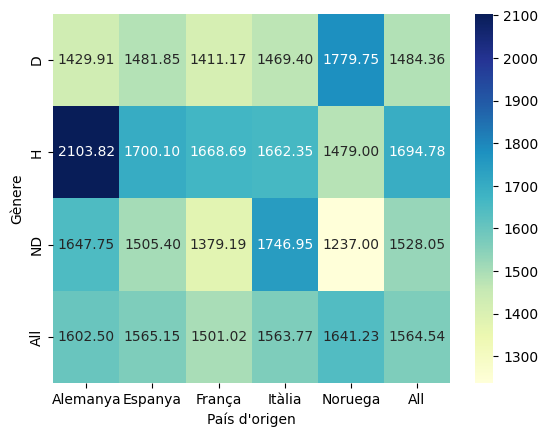

In [1241]:

sns.heatmap(pd.crosstab(df['Gènere'], df["País d'origen"], values=df['Salari mensual'], aggfunc='mean', margins=True), cmap="YlGnBu", annot=True, fmt=".2f")

# **Nivell 2 - Anàlisi amb dades enriquides i estructures múltiples**

Per a aquest nivell, es facilita informació externa que simula dades reals utilitzades per una empresa en processos d'anàlisi i presa de decisions salarials.

» **Fitxer JSON de política salarial**: L'empresa disposa d'un fitxer JSON que defineix les regles d'increment salarial anual. Aquest document estableix increments base per grup professional i ajustos addicionals segons factors personals (edat, fills) i contextuals. Aquest tipus d'estructura és habitual en sistemes interns de recursos humans, ja que permet modificar les polítiques sense alterar el codi.

» **Fitxer CSV de ciutats europees**: Es proporciona també un fitxer CSV amb informació contextual sobre diverses ciutats europees (país, índex de cost de vida, qualitat del transport públic i tipus de clima). Aquest dataset representa una font externa de dades utilitzada per enriquir l'anàlisi salarial en funció de l'entorn geogràfic on resideix cada persona.

# **Exercici 1: Enriquiment mitjançant datasets externs**

🎯 **Objectiu:** ampliar el dataset principal integrant informació contextual externa i avaluar l'impacte analític de les decisions de fusió.

**Aspectes a revisar i analitzar**

» Les diferents fonts de dades són coherents i compatibles entre si per poder calcular un salari ajustat?

» La informació contextual incorporada (cost de vida, polítiques salarials) és suficient per aplicar increments de manera consistent?

» Hi ha buits d'informació que impedeixin calcular correctament l'increment salarial en alguns registres?

» És necessari prendre decisions analítiques quan la informació contextual és parcial o absent?

» Com poden aquestes decisions influir en el càlcul del salari ajustat i en la seva interpretació posterior?

**Concretament, hauràs de:**

» Integrar el dataset principal amb:
*   El dataset contextual de ciutats.
*   La política salarial definida en format JSON

» Calcular un increment salarial total combinant:
*   Grup professional.
*   Situació familiar.
*   Franja d'edat.
*   Cost de vida de la ciutat.

» Identificar quins registres no poden rebre algun dels ajustos i explicar-ne el motiu.

» Decidir, de manera raonada, com tractar aquests casos en el càlcul del salari ajustat, justificant l'impacte analític de la decisió presa.

# **Disseny i implementació de la solució**

## 💢 **Dades**

Disposem de dos arxius amb informació addicional que hem guardat a una carpeta del drive:
*   Fitxer JSON de política salarial
*   Fitxer CSV de ciutats europees





In [1242]:

# Ruta on tenim els arxius guardats
path_ciutats = '/content/drive/My Drive/Data_Analytics/ciutats_context.csv'
path_politica_salarial = '/content/drive/My Drive/Data_Analytics/politica_salarial.json'


## 🧠 **Algoritme inicial**

1. Carregar el fitxer csv de ciutats com a dataframe.
2. Carregar el fitxer json de politica salarial com a diccionari.
3. Unir el dataframe de ciutats amb el dataframe de treballadors.
4. Calcular increment salarial.
6. Detectar incidències.

## 🧩 **Implementació de les funcions**

### **1. Carregar ciutats**

Carreguem el datase de ciutats on hi trobem informació contextual relacionada amb la ciutat:
*   **índex del cost de la vida**: informació numèrica en un rang de 0 a 100.
*   **qualitat del transport públic:** informació numèrica en un rang de 0  a 10.
*   **tipus de clima:** informació alfanumèrica (Mediterrani, Continental...)

Apliquem la funció que hem definit anteriorment per solucionar problemes de codificació.

In [1243]:
def carregar_ciutats(path):
# Funció que llegeix l'arxiu que es troba a la ruta del paràmetre i guarda les dades en un dataframe

  print("1. CÀRREGA DATASET DE CIUTATS")
  df_ciutats = pd.read_csv(path, sep = ",", header=0, encoding='latin1')
  correccions_codificacio (df_ciutats, "")
  display(df_ciutats)

  return df_ciutats

### **2. Carregar política salarial**

Carreguem el fitxer json on tenim la politica salarial de l'empresa i guardem les dades en un dicionari.
En aquest arxiu es defineixen els percentatges d'increment salarial en funció de diferents paràmetres:
*   **Grup professional:** A(5%), B(3.5%), C(2%), D(8%)
*   **Fills:** si té fills (1.5%), si no té fills (0%)
*   **Edat:** 18-29 (05), 30-44(1%), 45-59(2%), 60+ (1.5%)
*   **Cost de la vida:** low (0%), medium (1%), high(2%)
*   **Transport:** low (0.5%), medium(0%), high (-0,5%)

També  hi ha unes normes generals per aplicar els increments:
*   **max_total_increment_percent:** 15 (increment màxim percentual)
*   **min_salary_threshold:** 800 (llindar de salari mínim)

Cal fer algunes consideracions:
*   **cost de la vida:** a l'arxiu de ciutats tenim un valor numèric i aquí tenim un valor categòric. Haurem de definir què vol dir que el cost de la vida és baix, mitjà o alt.
*   **Qualitat del transport:** a l'arxiu de ciutats tenim un valor numèric i aquí tenim un valor categòric. Haurem de definir què vol dir que la qualitat del transport és baixa, mitjana o alta.
*   Entenem que com a màxim podem aplicar un 15% d'increment salarial.
*   Entenem que el salari mínim ha de ser de 800€. Si un cop aplicat l'increment el valor és inferior haurem de forçar el valor a 800€.








In [1244]:
def carregar_politica_salarial(path):
  # Obre l'arxiu que es troba a la ruta path i guarda les dades en un dicionari

  print("2. CÀRREGA POLÍTICA SALARIAL")
  with open(path, encoding = 'utf-8') as fitxer:
    dict = json.load(fitxer)

  print(json.dumps(dict, indent=4, ensure_ascii=False))
  return dict


### **3. Unir treballadors amb ciutats**

Fem un **merge** per ajuntar el dataframe de treballadors amb la informació que hi ha al dataframe de ciutats. Cal enllaçar per **dos camps** (ciutat i pais) ja que hi ha ciutats amb el mateix nom però de països diferents (Paris, Valencia).

In [1245]:
def unir_dades(df1, df2):

  print("3. UNIR TREBALLADORS AMB CIUTATS")
  df_final = pd.merge (df1, df2, left_on=['Ciutat', "País d'origen"], right_on=['Ciutat','País'], how='left')
  return df_final


### **4. Calcular increment salarial**

Tal com hem dit abans per calcular l'increment salarial cal definir els rangs de l'índex del cost de la vida i de la qualitat del transport.

Definim els següents rangs per l'**índex del cost de la vida**:
*   low: 0 - 59
*   medium: 60 - 84
*   high: >= 85

Definim els següents rangs per la puntuació de la **qualitat del tranport**:
*   low: 0 - 5.9
*   medium: 6.0 - 8.4
*   high: >=8.5



In [1246]:
from datetime import date
from dateutil.relativedelta import relativedelta

def calcular_increment(treballador, politica_salarial):
    grup = treballador['Grup Professional']
    te_fills = treballador['Fills']
    cost_vida = treballador['Cost_vida_index']
    transport = treballador['Transport_public_score']
    inc_max = politica_salarial['rules']['max_total_increment_percent']

    # Càlcul edat
    if treballador['Any de Naixement'] != 9999.0:
      data_naixement = date(int(treballador['Any de Naixement']), int(treballador['Mes de Naixement']), int(treballador['Dia de Naixement']))
      avui = date.today()
      edat = relativedelta(avui, data_naixement).years
    else:
      edat = np.nan

    # Inicialitzem la variable on guardarem l'increment
    total_increment = 0.0

    # 1. Calculem l'increment que correspon en funció del grup professional
    total_increment += politica_salarial['base_increment_by_group'].get(grup, 0.0)

    # 2. Acumulem l'increment que correspon en funció de si té fills o no
    if te_fills == True:
        total_increment += politica_salarial['children_adjustment']['has_children']
    elif te_fills == False:
        total_increment += politica_salarial['children_adjustment']['no_children']

    # 3. Acumulem increment en funció de l'edat (suposem que som a l'any 2025)
    if not pd.isna(edat) : # Comprovem edat diferent de nul
        if 18 <= edat <= 29:
            total_increment += politica_salarial['age_adjustment']['18-29']
        elif 30 <= edat <= 44:
            total_increment += politica_salarial['age_adjustment']['30-44']
        elif 45 <= edat <= 59:
            total_increment += politica_salarial['age_adjustment']['45-59']
        elif edat >= 60:
            total_increment += politica_salarial['age_adjustment']['60+']

    # 4. Acumulem increment en funció del cost de vida de la ciutat on viu el treballador
    if not pd.isna(cost_vida):
        if 0<= cost_vida <= 59:
            total_increment += politica_salarial['cost_of_living_adjustment']['low']
        elif 60 <= cost_vida <= 84:
            total_increment += politica_salarial['cost_of_living_adjustment']['medium']
        elif cost_vida >= 85:
            total_increment += politica_salarial['cost_of_living_adjustment']['high']

    # 5. Acumulem increment en funció del transport
    if not pd.isna(transport):
        if 0<= transport <= 5.9:
            total_increment += politica_salarial['transport_adjustment']['low']
        elif 6 <= transport <= 8.4:
            total_increment += politica_salarial['transport_adjustment']['medium']
        elif transport >= 8.5:
            total_increment += politica_salarial['transport_adjustment']['high']

    # Si l'increment supera el màxim assignem el valor màxim defint al diccionari
    if total_increment < inc_max:
      return total_increment
    else:
      return inc_max

In [1247]:
def calcular_sou_ajustat(df, dict):
  print("4. CÀLCUL SALARI AJUSTAT")
  # Calculem percentatge d'increment salarial que cal aplicar
  df['increment_percent'] = df.apply(calcular_increment, axis=1, args = (dict,))
  # Calculem salari ajustat tenint en compte el llindar de salari mínim
  min_sal = dict['rules']['min_salary_threshold']
  salari = df['Salari mensual'] * (1 + df['increment_percent'] / 100)
  df['Salari_ajustat'] = np.where (salari < min_sal, min_sal, salari)


### **5. Detectar incidències**

Hi ha alguns treballadors que no tenen la data de naixement informada i per tant no podem aplicar els increments relacionats amb l'edat.
També hi ha alguns treballadors que no tenen correspondència en el dataset de ciutats i per tant no podem aplicar els increments relacionats amb el cost de vida i el transport públic.
En aquest casos apliquem la resta d'increments. Com que tots els treballadors tenen un grup professional assignat tots tenen l'increment base.
Els altres increments només s'apliquen si disposem de l'informació.

In [1248]:
def incidencies(df):
  print("5. INCIDÈNCIES")
  print("Registres amb grup professional nul:", df['Grup Professional'].isna().sum())
  print("Registres amb any de naixement no definit:", df[df['Any de Naixement']==9999]['DNI'].count())
  print("Registres amb cost de vida nul:", df['Cost_vida_index'].isna().sum())



## **⭕ Funció principal**

In [1249]:
def main_actualitzacio_salari(df):

  df_ciutats = carregar_ciutats(path_ciutats)
  dict_politica_salarial = carregar_politica_salarial(path_politica_salarial)
  df = unir_dades(df, df_ciutats)
  calcular_sou_ajustat(df, dict_politica_salarial)
  incidencies(df)

  mostrar_dataframe(df, "DATAFRAME ACTUALITZAT")
  return df

## ▶ **Execució**

In [1250]:
df = main_actualitzacio_salari(df)

1. CÀRREGA DATASET DE CIUTATS

    Corregim els noms de les columnes...
    Corregim els valors de text de les columnes 'object'...


,Ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus
0,Barcelona,Espanya,78,8.5,Mediterrani
1,Madrid,Espanya,75,8.0,Continental
2,València,Espanya,70,7.5,Mediterrani
3,Sevilla,Espanya,65,7.0,Mediterrani
4,Bilbao,Espanya,72,7.8,Oceànic
5,Zaragoza,Espanya,68,7.0,Continental
6,Murcia,Espanya,60,6.5,Mediterrani
7,Palma,Espanya,73,7.2,Mediterrani
8,Girona,Espanya,66,6.8,Mediterrani
9,Tarragona,Espanya,67,6.9,Mediterrani


2. CÀRREGA POLÍTICA SALARIAL
{
    "base_increment_by_group": {
        "Grup A": 5.0,
        "Grup B": 3.5,
        "Grup C": 2.0,
        "Grup D": 8.0
    },
    "children_adjustment": {
        "has_children": 1.5,
        "no_children": 0.0
    },
    "age_adjustment": {
        "18-29": 0.0,
        "30-44": 1.0,
        "45-59": 2.0,
        "60+": 1.5
    },
    "cost_of_living_adjustment": {
        "low": 0.0,
        "medium": 1.0,
        "high": 2.0
    },
    "transport_adjustment": {
        "low": 0.5,
        "medium": 0.0,
        "high": -0.5
    },
    "rules": {
        "max_total_increment_percent": 15,
        "min_salary_threshold": 800
    }
}
3. UNIR TREBALLADORS AMB CIUTATS
4. CÀLCUL SALARI AJUSTAT
5. INCIDÈNCIES
Registres amb grup professional nul: 0
Registres amb any de naixement no definit: 77
Registres amb cost de vida nul: 136

DATAFRAME ACTUALITZAT


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,...,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus,increment_percent,Salari_ajustat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,D,1469.0,...,True,32108.0,25.0,10.1,Espanya,64.0,6.7,Continental,7.5,1579.175
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,2718.0,...,True,19496.0,10.4,18.7,Espanya,68.0,7.0,Mediterrani,4.5,2840.310
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358.0,...,False,0.0,0.0,16.7,Espanya,68.0,7.0,Mediterrani,9.0,1480.220
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,1478.0,...,False,0.0,0.0,18.3,Espanya,65.0,7.0,Mediterrani,7.0,1581.460
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,D,1284.0,...,True,0.0,11.8,13.1,Espanya,72.0,7.8,Oceànic,6.0,1361.040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,Jordi,Hernández,67755039Y,Espanya,Zaragoza,12.0,10.0,1961.0,D,1074.0,...,True,80000.0,12.0,12.0,Espanya,68.0,7.0,Continental,9.0,1170.660
985,Chloé,Dubois,66354268T,França,Nice,2.0,12.0,1958.0,H,1954.0,...,False,0.0,0.0,11.7,NaN,NaN,NaN,NaN,6.5,2081.010
986,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,H,2010.0,...,False,0.0,0.0,-10.0,Espanya,73.0,7.2,Mediterrani,5.5,2120.550
987,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,1073.0,...,False,0.0,0.0,15.8,Espanya,67.0,6.9,Mediterrani,6.0,1137.380


# **Exercici 2: Reestructuració del dataset**

🎯 **Objectiu:** preparar el dataset per a anàlisis comparatives i/o visuals. Convertir informació dispersa en format llarg:
*   Salaris
*   Mobilitat
*   Context climàtic etc

**Aspectes a revisar i analitzar**

» Existeixen variables que representen conceptes similars o relacionats, però estan distribuïdes en diferents columnes?

»El format actual del dataset facilita o dificulta:

*   comparacions entre magnituds.
*   agregacions per grups.

» Quin impacte té la forma del dataset (ample vs llarg) en la lectura i interpretació de les dades?

**Concretament, hauràs de:**

» Reestructurar el dataset utilitzant melt() per convertir-lo a format llarg, definint prèviament:

*   les columnes que actuen com a identificadores (per exemple: persona, ciutat, grup professional, gènere, etc.).
*  les columnes que passen a representar valors mesurats (per exemple: salaris, mobilitat, variables contextuals).

» Analitzar per què el format llarg és més adequat per:

*   realitzar comparacions entre diferents tipus de variables.
*   calcular estadístics agregats.



# **Disseny i implementació de la solució**

En el dataset que estem treballant veiem que hi ha informació relacionada però que està en diferents columnes:

*   **dades mobilitat:** Te_cotxe, Km_anuals, Consum_mitja_L_100km, Transport_public_score
*   **dades salarials** (relacionades amb Grup professional i Càrrec): Salari mensual, increment_percent, Salari_ajustat
*   **dades contextuals** (relacionades amb Ciutat i País): Cost_vida_index,Temperatura_mitjana_ciutat, clima_tipus

El format actual (**format ample**) és adequat per analitzar la informació d'un treballador concret però dificulta les comparacions i els càlculs agrupats de les variables relacionades. En aquest cas és millor treballar amb el **format llarg** que podem obtenir a partir de la funció **melt()**.


## 🧠 **Passos a realitzar**

1. Definir els grups de variables.
2. Conversió a format llarg amb dades de mobilitat.
3. Conversió a format llarg amb dades salarials.
4. Conversió a format llarg amb dades contextuals.
5. Anàlisi de les avantatges de treballar en format llarg.

### **1. Definició de variables**

In [1251]:
columnes_identificacio = [
    'Nom', 'Cognoms', 'DNI', "País d'origen", 'Ciutat',
    'Dia de Naixement', 'Mes de Naixement', 'Any de Naixement', 'Gènere',
    'Grup Professional', 'Càrrec'
]

dades_mobilitat = ['Km_anuals', 'Consum_mitja_L_100km', 'Transport_public_score']
dades_salarials = ['Salari mensual', 'increment_percent', 'Salari_ajustat']
dades_contextuals = [ 'Nombre_fills', 'Cost_vida_index','Temperatura_mitjana_ciutat', 'Clima_tipus']


### **2. Conversió a format llarg amb dades de mobilitat**

In [1252]:
df_llarg_mobilitat = df.melt(id_vars = columnes_identificacio, value_vars=dades_mobilitat)
df_llarg_mobilitat

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Grup Professional,Càrrec,variable,value
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,D,Grup B,Cap de projecte,Km_anuals,32108.0
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,Grup C,Analista,Km_anuals,19496.0
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,Grup A,Tècnic IT,Km_anuals,0.0
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,Grup B,Analista,Km_anuals,0.0
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,D,Grup B,Administratiu,Km_anuals,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,Jordi,Hernández,67755039Y,Espanya,Zaragoza,12.0,10.0,1961.0,D,Grup A,Analista,Transport_public_score,7.0
2963,Chloé,Dubois,66354268T,França,Nice,2.0,12.0,1958.0,H,Grup B,Analista,Transport_public_score,NaN
2964,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,H,Grup C,Analista,Transport_public_score,7.2
2965,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,Grup A,Administratiu,Transport_public_score,6.9


### **3. Conversió a format llarg amb dades salarials**

In [1253]:
df_llarg_salarial = df.melt(id_vars = columnes_identificacio, value_vars=dades_salarials)
df_llarg_salarial

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Grup Professional,Càrrec,variable,value
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,D,Grup B,Cap de projecte,Salari mensual,1469.00
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,Grup C,Analista,Salari mensual,2718.00
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,Grup A,Tècnic IT,Salari mensual,1358.00
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,Grup B,Analista,Salari mensual,1478.00
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,D,Grup B,Administratiu,Salari mensual,1284.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,Jordi,Hernández,67755039Y,Espanya,Zaragoza,12.0,10.0,1961.0,D,Grup A,Analista,Salari_ajustat,1170.66
2963,Chloé,Dubois,66354268T,França,Nice,2.0,12.0,1958.0,H,Grup B,Analista,Salari_ajustat,2081.01
2964,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,H,Grup C,Analista,Salari_ajustat,2120.55
2965,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,Grup A,Administratiu,Salari_ajustat,1137.38


### **4. Conversió a format llarg amb dades contextuals**

In [1254]:
df_llarg_contextual = df.melt(id_vars = columnes_identificacio, value_vars=dades_contextuals)
df_llarg_contextual

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Grup Professional,Càrrec,variable,value
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,D,Grup B,Cap de projecte,Nombre_fills,3.0
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,Grup C,Analista,Nombre_fills,0.0
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,Grup A,Tècnic IT,Nombre_fills,4.0
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,Grup B,Analista,Nombre_fills,2.0
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,D,Grup B,Administratiu,Nombre_fills,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3951,Jordi,Hernández,67755039Y,Espanya,Zaragoza,12.0,10.0,1961.0,D,Grup A,Analista,Clima_tipus,Continental
3952,Chloé,Dubois,66354268T,França,Nice,2.0,12.0,1958.0,H,Grup B,Analista,Clima_tipus,NaN
3953,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,H,Grup C,Analista,Clima_tipus,Mediterrani
3954,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,Grup A,Administratiu,Clima_tipus,Mediterrani


### **5. Anàlisi de les avantatges de treballar en format llarg**

El format llarg facilita les **comparacions** entre diferents variables ja que en tenir tots els valors mesurats en una mateixa columna, és més fàcil comparar estadístiques entre ells.
Per exemple, pots comparar la mitjana de salaris mensual amb la mitjana del salari ajustat i l'increment dins del mateix groupby amb poques línies de codi.

In [1255]:

df_llarg_salarial.groupby('variable')['value'].mean().round(2)

,value
variable,
Salari mensual,1564.54
Salari_ajustat,1668.86
increment_percent,6.74


També facilita els **càlculs estadístics agregats** ja que totes les variables que volem analitzar estan a la mateixa columna. Això redueix la complexitat i augmenta la flexibilitat per a l'anàlisi de dades agregades.

En el següent exemple veiem com calcular la mitjana, la mediana, el mínim i el màxim de les variables de mobilitat agrupades per Grup Professional utilitzant el format llarg.

In [1256]:
df_llarg_mobilitat.groupby(['Grup Professional', 'variable'])['value'].agg(['mean', 'median', 'min', 'max']).round(2)

mean  median  min        max
Grup Professional variable                                                
Grup A            Consum_mitja_L_100km        2.96     0.0  0.0       25.0
                  Km_anuals               18713.01     0.0  0.0  1000000.0
                  Transport_public_score      7.29     7.1  6.5        9.2
Grup B            Consum_mitja_L_100km        2.86     0.0  0.0       25.0
                  Km_anuals               17636.77     0.0  0.0   118147.0
                  Transport_public_score      7.29     7.1  6.5        9.2
Grup C            Consum_mitja_L_100km        2.46     0.0  0.0       25.0
                  Km_anuals               14930.30     0.0  0.0   113145.0
                  Transport_public_score      7.37     7.2  6.5        9.2
Grup D            Consum_mitja_L_100km        3.86     0.0  0.0       25.0
                  Km_anuals               14939.70     0.0  0.0    80000.0
                  Transport_public_score      7.29     7.2  6.5        8.1

Fem el mateix utilitzant el format ample i veiem que el codi a utilitzar és més complicat.

In [1257]:
df.groupby('Grup Professional').agg({'Consum_mitja_L_100km':['mean','median','min','max'], 'Km_anuals':['mean','median','min','max'], 'Transport_public_score':['mean','median','min','max']}).round(2)

Consum_mitja_L_100km                   Km_anuals         \
                                  mean median  min   max      mean median   
Grup Professional                                                           
Grup A                            2.96    0.0  0.0  25.0  18713.01    0.0   
Grup B                            2.86    0.0  0.0  25.0  17636.77    0.0   
Grup C                            2.46    0.0  0.0  25.0  14930.30    0.0   
Grup D                            3.86    0.0  0.0  25.0  14939.70    0.0   

                                  Transport_public_score                   
                   min        max                   mean median  min  max  
Grup Professional                                                          
Grup A             0.0  1000000.0                   7.29    7.1  6.5  9.2  
Grup B             0.0   118147.0                   7.29    7.1  6.5  9.2  
Grup C             0.0   113145.0                   7.37    7.2  6.5  9.2  
Grup D             0.0    80000.0                   7.29    7.2  6.5  8.1

# **Exercici 3: Creació de variables derivades (Feature Engineering)**

🎯 **Objectiu:** generar noves variables derivades a partir de la informació existent i avaluar-ne la qualitat analítica. Tot i que algunes variables de base (com l’edat o el salari) ja han estat introduïdes en exercicis anteriors, en aquest nivell no es valora la seva creació tècnica, sinó la capacitat de transformar-les en indicadors més informatius, la detecció de casos límit o incoherents i la reflexió sobre la utilitat real de les variables generades en un context analític.

**Exemples (tria guiada):**

» Índex de dependència familiar: Salari mensual / (Nombre fills + 1).

» Índex de mobilitat: Km anuals / Temperatura mitjana.

» Ràtio: salari / cost de vida.

» Indicador de dependència familiar: Salari / Nombre fills.

» Pes de responsabilitat familiar: Nombre fills * Edat.

» Indicador de etapa vital: 0 → sense càrregues, 1 → etapa activa, 2 → alta dependència.

**Concretament, hauràs de:**

» Crear almenys 3 variables derivades.

» Justificar:
*   La seva utilitat analítica.
*   Les decisions preses.

» Detectar casos límit o incoherents generats per les noves variables.

# **Disseny i implementació de la solució**

### **1. Índex de dependència familiar**

Calculem l'índex de dependència familiar dividint el salari mensual pel nombre de fills més 1.

Aquest índex ens dóna una idea de la disponibilitat financera per cada membre de la família. Un mateix salari aporta un poder adquisitiu diferent si s'ha de pagar només les despeses del treballador o si cal assumir també les despeses dels fills.

Així si tenim dos treballadors amb el mateix salari el que tingui més fills tindrà un índex de dependència familiar més petit és a dir tindrà menys diners disponibles per cada membre de la família.

Per un treballador sense fills l'índex de dependència familiar és igual al salari mensual ja que dividim per 1.

En la fórmula dividim per nombre de fills més 1 ja que si dividim només per nombre de fills en els casos que el nombre de fills és 0 ens donaria error.

In [1258]:
# Calculem l'índex de dependència familiar
df['Dependencia'] = df['Salari mensual']/(df['Nombre_fills']+1).round(2)
# Mostrem algunes dades i l'índex calculat dels 15 primers registres
df[['Nom','Ciutat','Grup Professional','Salari mensual','Nombre_fills','Dependencia']].head(15)

,Nom,Ciutat,Grup Professional,Salari mensual,Nombre_fills,Dependencia
0,Joana,Valladolid,Grup B,1469.0,3.0,367.250000
1,Marc,Alacant,Grup C,2718.0,0.0,2718.000000
2,Noa,Alacant,Grup A,1358.0,4.0,271.600000
3,Pol,Sevilla,Grup B,1478.0,2.0,492.666667
4,David,Bilbao,Grup B,1284.0,0.0,1284.000000
5,Alexia,Las Palmas de Gran Canaria,Grup B,2069.0,0.0,2069.000000
6,David,Palma,Grup B,2349.0,0.0,2349.000000
7,Carmen,Barcelona,Grup C,2855.0,4.0,571.000000
8,Nora,Stavanger,Grup B,1338.0,0.0,1338.000000
9,Alba,Las Palmas de Gran Canaria,Grup A,1450.0,4.0,290.000000


### **2. Índex de mobilitat**

Calculem l'índex de mobilitat dividint els quilòmetres anuals efectuats pel treballador per la temperatura mitjana de la ciutat on resideix.

Aquest índex intenta reflexar la relació entre la mobilitat i el clima d'un lloc concret.

Analitzem els casos límit:

*   Km_anuals = 0 --> l'índex és 0
*   Temp_mitjana = 0 --> forcem a nul ja que la divisió donaria error
*   Temp_mitjana <0  --> l'índex és negatiu

La relació entre mobilitat i clima no és lineal ja que tant la calor extrema com el fred extrem redueixen la mobilitat i això no es pot representar amb una divisió.

Des del meu punt de vista aquest índex té poca utilitat analítica ja que no ens dóna gaire informació.

In [1259]:
# Calculem l'índex de mobilitat
df['Mobilitat'] = np.where(df['Temperatura_mitjana_ciutat'] != 0, df['Km_anuals']/df['Temperatura_mitjana_ciutat'], np.nan)

# Mostrem algunes dades i l'índex calculat dels 15 primers registres
df[['Nom','Ciutat','Grup Professional','Km_anuals','Temperatura_mitjana_ciutat','Mobilitat']].head(15)


,Nom,Ciutat,Grup Professional,Km_anuals,Temperatura_mitjana_ciutat,Mobilitat
0,Joana,Valladolid,Grup B,32108.0,10.1,3179.009901
1,Marc,Alacant,Grup C,19496.0,18.7,1042.566845
2,Noa,Alacant,Grup A,0.0,16.7,0.000000
3,Pol,Sevilla,Grup B,0.0,18.3,0.000000
4,David,Bilbao,Grup B,0.0,13.1,0.000000
5,Alexia,Las Palmas de Gran Canaria,Grup B,0.0,19.9,0.000000
6,David,Palma,Grup B,6196.0,17.8,348.089888
7,Carmen,Barcelona,Grup C,20000.0,15.4,1298.701299
8,Nora,Stavanger,Grup B,0.0,7.6,0.000000
9,Alba,Las Palmas de Gran Canaria,Grup A,0.0,20.1,0.000000


### **3. Ràtio salarial**

Calculem la ràtio dividint el salari mensual per l'índex del cost de la vida.

Aquesta ràtio ens dona una idea més real del poder adquisitiu que té un treballador concret ja que tenim en compte el cost de la vida de la ciutat on resideix el treballador.

Així si tenim dos treballadors amb el mateix salari el que tingui el cost de vida més alt tindrà una ràtio més petita i per tant menys poder adquisitiu.


In [1260]:
# Calculem la ratio salarial
df['Ratio'] = (df['Salari mensual']/df['Cost_vida_index']).round(2)
# Mostrem algunes dades i la ràtio calculada dels 15 primers registres
df[['Nom','Ciutat','Grup Professional','Salari mensual','Cost_vida_index','Ratio']].head(15)

,Nom,Ciutat,Grup Professional,Salari mensual,Cost_vida_index,Ratio
0,Joana,Valladolid,Grup B,1469.0,64.0,22.95
1,Marc,Alacant,Grup C,2718.0,68.0,39.97
2,Noa,Alacant,Grup A,1358.0,68.0,19.97
3,Pol,Sevilla,Grup B,1478.0,65.0,22.74
4,David,Bilbao,Grup B,1284.0,72.0,17.83
5,Alexia,Las Palmas de Gran Canaria,Grup B,2069.0,62.0,33.37
6,David,Palma,Grup B,2349.0,73.0,32.18
7,Carmen,Barcelona,Grup C,2855.0,78.0,36.60
8,Nora,Stavanger,Grup B,1338.0,NaN,NaN
9,Alba,Las Palmas de Gran Canaria,Grup A,1450.0,62.0,23.39


Observem que hi ha alguns treballadors que no tenen cost de vida informat ja que la ciutat on resideixen no està inclosa a l'arxiu de ciutats que conté aquesta informació. Per aquests treballador tampoc podem calcular la ratio.
Hi ha 136 treballadors sense ratio que resideixen a les següents ciutats.

In [1261]:
print("Número de registres amb ratio nula:", df[df['Ratio'].isna()]['DNI'].count())
df[df['Ratio'].isna()].groupby('Ciutat')['DNI'].count()

Número de registres amb ratio nula: 136


,DNI
Ciutat,
Bologna,11
Düsseldorf,5
Köln,4
Màlaga,54
München,5
Nantes,12
Nice,11
Stavanger,9
Toulouse,15


# **Exercici 4: Exportació i síntesi de resultats**

🎯 **Objectiu:** consolidar els resultats obtinguts després de la preparació, enriquiment i creació de variables, i generar sortides estructurades reutilitzables per a anàlisi o reporting.
En aquest exercici es vol posar el **focus** en:

» L'organització de les dades per grups rellevants.

» La generació de datasets finals coherents.

» La capacitat de sintetitzar informació clau.

**Aspectes a revisar i analitzar:**

» Quin nivell d'agrupació és més adequat per a l'exportació de resultats?

» Com separar dades detallades de dades agregades?

» Quina informació és rellevant per a un ús posterior (anàlisi, visualització, reporting)?

**Concretament, hauràs de:**

» Utilitzant un bucle, exportar en 4 fitxers (format .csv o .xlsx) les dades corresponents a cada Grup Professional. Per exemple: dades_GrupA.csv, dades_GrupB.csv...

» Crear i exportar un cinquè DataFrame (format .csv o .xlsx) que contingui, per a cada Grup Professional:
  *   Nombre total de treballadors.
  *   Salari mitjà.
  *   Edat mediana.

**EXTRA**

Explora com exportar tots els DataFrames en un únic fitxer Excel, utilitzant:

» Una pestanya per a cada Grup Professional.

» Una pestanya addicional amb el resum agregat.

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Exportar les **dades detallades** de cada grup professional en 4 fitxers separats.
2. Exportar les **dades agrupades** per grup professional en un fitxer mostrant:
  *   Nombre total de treballadors.
  *   Salari mitjà.
  *   Edat mediana.
3. Crear un fitxer excel amb **5 pestanyes** amb informació detallada i agrupada.

## 💢 **Dades**

En aquest exercici generem fitxers amb les dades que guardarem a la següent ruta.


In [1262]:
path_dades = '/content/drive/My Drive/Data_Analytics/dades/'

## 🧩 **Implementació de les funcions**

### **1. Exportar informació detallada**

Exportem les dades detallades corresponents a cada grup professional. Es creen 4 fitxers excel.

In [1263]:
def exportar_detall(df, path):
  for grup in df['Grup Professional'].unique():
    df_grup = df[df['Grup Professional'] == grup]
    df_grup.to_excel(f'{path}dades_{grup}.xlsx', index=False)
    print(f"Exportació detallada {grup}. Fitxers guardats a: {path}")

### **2. Exportar informació agrupada**

Exportem una taula resum per grup professional amb el número de treballadors, el salari mitjà i la mediana de l'any de naixement. Es crea un fitxer excel.

In [1264]:
def exportar_dades_agrupades(df, path):
    df_grup = df.groupby('Grup Professional').agg({'DNI':'count','Salari mensual': 'mean', 'Any de Naixement': 'median'})
    df_grup.to_excel(f'{path}dades_agrupades.xlsx', index = True)
    print(f"Exportació agrupada. Fitxers guardats a: {path}")


### **3. Exportar informació detallada i agrupada**

Exportem en el mateix fitxer excel les dades detallades i agrupades en fulls diferents.

In [1265]:
def exportar_dades_totals(df, path):

    df_grupA = df[df['Grup Professional'] == 'Grup A']
    df_grupB = df[df['Grup Professional'] == 'Grup B']
    df_grupC = df[df['Grup Professional'] == 'Grup C']
    df_grupD = df[df['Grup Professional'] == 'Grup D']
    df_grup = df.groupby('Grup Professional').agg({'DNI':'count','Salari mensual': 'mean', 'Any de Naixement': 'median'})

    with pd.ExcelWriter(path + 'dades_totals.xlsx') as writer:
      df_grupA.to_excel(writer, sheet_name ='Grup A')
      df_grupB.to_excel(writer, sheet_name ='Grup B')
      df_grupC.to_excel(writer, sheet_name ='Grup C')
      df_grupD.to_excel(writer, sheet_name ='Grup D')
      df_grup.to_excel(writer, sheet_name ='resum')

    print(f"Exportació detallada i agrupada. Fitxers guardats a: {path}")

## **⭕ Funció principal**

In [1266]:
def main_exportacio (df):
  exportar_detall(df, path_dades)
  exportar_dades_agrupades(df, path_dades)
  exportar_dades_totals(df, path_dades)

## ▶ **Execució**

In [1267]:
main_exportacio(df)

Exportació detallada Grup B. Fitxers guardats a: /content/drive/My Drive/Data_Analytics/dades/
Exportació detallada Grup C. Fitxers guardats a: /content/drive/My Drive/Data_Analytics/dades/
Exportació detallada Grup A. Fitxers guardats a: /content/drive/My Drive/Data_Analytics/dades/
Exportació detallada Grup D. Fitxers guardats a: /content/drive/My Drive/Data_Analytics/dades/
Exportació agrupada. Fitxers guardats a: /content/drive/My Drive/Data_Analytics/dades/
Exportació detallada i agrupada. Fitxers guardats a: /content/drive/My Drive/Data_Analytics/dades/


# **Nivell 3 - Exploració visual i optimització aplicada**

En aquest nivell es treballa amb un dataset ja ric i complex, amb múltiples variables personals, salarials, contextuals i derivades. L'objectiu no és continuar netejant dades, sinó extreure valor ràpidament i aplicar el dataset a un problema pràctic.

El nivell es divideix en dos exercicis:

» Exploració visual automatitzada, per obtenir una visió global del dataset, detectar patrons, anomalies o relacions rellevants sense anàlisi manual exhaustiva.

» Resolució d'un problema aplicat, on les dades serveixen com a suport per prendre decisions operatives reals, encara que la solució no sigui matemàticament òptima.

👉 El focus està en el criteri analític, la capacitat de síntesi i la justificació de decisions, no en la perfecció tècnica.

# **Exercici 1: Exploració visual del dataset**

🌍 **Context:** Es disposa d'un DataFrame amb un volum elevat de variables. Abans de qualsevol anàlisi específica, és necessari disposar de mecanismes que permetin explorar el dataset de manera ràpida i sistemàtica.

Aquest exercici se centra en crear una funció que ajudi a crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple, un histograma/boxplot si la variable és numèrica, unes barres dels valors més freqüents si és categòrica i unes barres dels anys més freqüents si la dada està en format data.

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Carregar dataframe de prova
2. Per cada columna del dataframe
    *   Si és numèrica crear histograma
    *   Si és categòriaca o data crear diagrama de barres
    *   Exportar el gràfic en un arxiu

## 💢 **Dades**

Gravarem els arxius amb els gràfics generats a la carpeta Data_Analytics/gràfics del Drive.

In [1268]:
path_grafics = '/content/drive/My Drive/Data_Analytics/gràfics/'

## **⭕ Funció principal**

In [1269]:
def crear_grafic (df, path):
# Funció que crea i exporta un gràfic per cada columna del dataframe

  # Recorrem les columnes del dataframe
  for columna in df.columns:
    # Si la columna és numèrica fem un histograma
    if pd.api.types.is_numeric_dtype(df[columna]):
      print("Creació histograma per la columna numèrica:",columna)
      sns.histplot(data=df, x=columna)
      plt.title(f"Distribució: {columna}")
      plt.xlabel(columna)
      plt.ylabel("Freqüència")
    else:
      # En els altres casos fem un diagrama de barres
      print("Creació diagrama de barres per la columna:",columna)
      valors = df[columna].value_counts()
      sns.barplot(
                x=valors.values,
                y=valors.index,
                palette="viridis",
                hue=valors.index,
                legend=False
            )
      plt.title(f"Recompte de: {columna}")
      plt.xlabel("Recompte")
      plt.ylabel("Categoria")

    # Exportem el gràfic a un fitxer png
    ruta = path + columna + '_grafic.png'
    plt.savefig(ruta, dpi=300)
    plt.close()
  print("Els gràfics s'han gravat a la següent ubicació:",path)


## ▶ **Execució**

Carreguem el dataset "penguins" del paquet seaborn i provem la funció.

In [1270]:

df_penguins = sns.load_dataset("penguins")
display(df_penguins.head())
crear_grafic(df_penguins, path_grafics)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Creació diagrama de barres per la columna: species
Creació diagrama de barres per la columna: island
Creació histograma per la columna numèrica: bill_length_mm
Creació histograma per la columna numèrica: bill_depth_mm
Creació histograma per la columna numèrica: flipper_length_mm
Creació histograma per la columna numèrica: body_mass_g
Creació diagrama de barres per la columna: sex
Els gràfics s'han gravat a la següent ubicació: /content/drive/My Drive/Data_Analytics/gràfics/


# **Exercici 2: Optimització de rutes (problema aplicat)**

🌍 **Context:** L'empresa no disposa d'un control fiable del quilometratge dels desplaçaments dels seus treballadors. Abans d'implementar un sistema avançat, es vol fer una prova pilot amb treballadors ubicats a Espanya.

**Per a aquesta prova:**

» Es treballa amb una matriu de distàncies entre ciutats.

» Es vol una solució simple, raonable i explicable.

» No es busca la ruta òptima, sinó una aproximació coherent.

Carrega l'arxiu **matriu_distancies.xlsx** a pandas de manera que les files i columnes siguin les ciutats i s'eliminin "Las Palmas de Gran Canaria" i "Palma".

**Desenvolupa una funció que:**

» Rebi: una ciutat d'origen i una ciutat de destinació.

» Retorni: l'ordre de les ciutats visitades (ruta) i la distància total recorreguda.

La ruta s'ha de construir seguint una estratègia senzilla: anar sempre a la ciutat no visitada més propera fins a arribar a la destinació.

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Carregar l'arxiu de distàncies en un dataframe.
2. Inicialitzar la variable on guardarem la ruta amb el valor de la ciutat origen.
3. Inicialitzar la distància total a 0.
4. Mentre l'última ciutat de la ruta sigui diferent de la ciutat destí:
    *   Buscar la ciutat més propera a aquesta ciutat que no estigui a la ruta.
    *   Afegir ciutat propera a la ruta
    *   Acumular la distància
5. Retornar ruta i distància total

## 💢 **Dades**

Disposem d'un arxiu excel amb les distàncies entre ciutats que tenim guardat al github. Carreguem l'arxiu i el guardem en un dataframe. També esborrem les files i columnes de les ciutats insulars per excloure-les de la prova.

In [1271]:
url_distancies = "https://raw.githubusercontent.com/roser740/Data-Analytics/main/TASQUES%20S8/matriu_distancies.xlsx"

df_distancies = pd.read_excel(url_distancies, header=0, index_col=0)
df_distancies.drop(index=['Las Palmas de Gran Canaria', 'Palma'], inplace=True)
df_distancies.drop(columns=['Las Palmas de Gran Canaria', 'Palma'], inplace=True)
df_distancies

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


## **⭕ Funció principal**

In [1272]:
def calcul_ruta (df_distancies, origen, desti):
  print(f'CÀLCUL RUTA ENTRE {origen} I {desti}')

  if (origen not in df_distancies.index) or (desti not in df_distancies.columns):
    print ("No tenim la informació de les ciutats a l'arxiu")
    return None, None
  else:
    # Inicialitzem la llista on guardarem les ciutats
    ruta = [origen]
    # Inicialitzem la distància total recorreguda
    distancia_total = 0
    # Mentre l'última ciutat de la llista sigui diferent del destí
    while ruta[-1] != desti:
      # Busquem la ciutat més propera de la fila que no estigui a la ruta
      distancia_min = float('inf') # Inicialitzem la variable amb el valor infinit positiu
      ciutat_propera = None
      for ciutat in df_distancies.columns: # Per cadascuna de les ciutats
        if ciutat not in ruta: # que no estiguin a la ruta
          distancia = df_distancies.loc[ruta[-1], ciutat] # busquem la distància
          if distancia < distancia_min: # si és menor que les anteriors la guardem
            distancia_min = distancia
            ciutat_propera = ciutat
      # Afegirm la ciutat més propera a la ruta
      ruta.append(ciutat_propera)
      # Acumulem la distància
      distancia_total += distancia_min

    # Quan sortim del bucle és perquè hem arribat al destí
    # Retornem la ruta i la distància
    return ruta, distancia_total



## ▶ **Execució**

Executem la funció calcul_ruta per diferents ciutats origen i destí.

In [1273]:

ruta, distancia = calcul_ruta (df_distancies, "Bilbao", "Sevilla")
print("Ruta:", ruta)
print(f"Distància total: {distancia} Km")
print("_________________________________________________________________________________")

ruta, distancia = calcul_ruta (df_distancies, "Vigo", "Málaga")
print("Ruta:", ruta)
print(f"Distància total: {distancia} Km")
print("_________________________________________________________________________________")

ruta, distancia = calcul_ruta (df_distancies, "Barcelona", "Zaragoza")
print("Ruta:", ruta)
print(f"Distància total: {distancia} Km")
print("_________________________________________________________________________________")

ruta, distancia = calcul_ruta (df_distancies, "Tarragona", "Gijón")
print("Ruta:", ruta)
print(f"Distància total: {distancia} Km")
print("_________________________________________________________________________________")



CÀLCUL RUTA ENTRE Bilbao I Sevilla
Ruta: ['Bilbao', 'Gijón', 'Valladolid', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla']
Distància total: 1648.0 Km
_________________________________________________________________________________
CÀLCUL RUTA ENTRE Vigo I Málaga
Ruta: ['Vigo', 'Gijón', 'Bilbao', 'Valladolid', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga']
Distància total: 2103.0 Km
_________________________________________________________________________________
CÀLCUL RUTA ENTRE Barcelona I Zaragoza
Ruta: ['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza']
Distància total: 257.0 Km
_________________________________________________________________________________
CÀLCUL RUTA ENTRE Tarragona I Gijón
No tenim la informació de les ciutats a l'arxiu
Ruta: None
Distància total: None Km
_________________________________________________________________________________
